<a href="https://colab.research.google.com/github/bepam/aulaspam/blob/main/EDA_Olist_Mackenzie_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 EDA — Olist E-commerce Dataset
## Análise Exploratória de Dados
### Linguagens de Programação para Dados & Analytics (Python e R)

> **Universidade Presbiteriana Mackenzie** · Prof. Domingos Napolitano · 2026

---

### 📖 Sobre o Dataset

A **Olist** é um marketplace brasileiro que conecta pequenos e médios lojistas a consumidores em todo o país.
Este dataset público contém **~100.000 pedidos** realizados entre **2016 e 2018**, organizados em **8 arquivos CSV interconectados**.

Ele é amplamente usado em cursos de Data Science por ser:
- 🇧🇷 Próximo da realidade do varejo digital brasileiro
- 🗃️ **Relacional** — múltiplas tabelas que se conectam por chaves
- 💡 Rico em **problemas reais** de qualidade de dados (a aprender a identificar!)

---

### 🎯 O que você vai aprender neste notebook

| Seção | Tema | Objetivo |
|-------|------|---------|
| **0** | Setup e Carregamento | Importar bibliotecas, carregar os 8 CSVs do GitHub |
| **1** | Schema Relacional | Entender como as tabelas se conectam |
| **2** | Diagnóstico de Qualidade | Mapear nulos, tipos errados e duplicatas |
| **3** | Análise de Pedidos | Volume, sazonalidade e status |
| **4** | Análise de Clientes | Geografia e a armadilha do `customer_id` |
| **5** | Análise de Produtos | Categorias, preços e outliers |
| **6** | Análise de Pagamentos | Formas de pagamento e ticket médio |
| **7** | Análise de Avaliações | Distribuição de notas e sentimento |
| **8** | Análise de Vendedores | Cobertura geográfica e gaps |
| **9** | Dataset Integrado | Merge das 7 tabelas em um único DataFrame |

---

> ⚠️ **Como usar:** Execute célula por célula com **Shift + Enter** para acompanhar o raciocínio,  
> ou **Runtime → Run all** para rodar tudo de uma vez.
>
> 🔎 Este notebook é de **exploração** — você vai *observar* os dados.  
> As correções e análises aprofundadas ficam para as **tarefas a seguir**.

---

---
## ⚙️ Seção 0 — Setup e Carregamento dos Dados

Antes de qualquer análise, preparamos o ambiente:
- Importamos as bibliotecas de análise e visualização
- Configuramos o estilo padrão dos gráficos
- Carregamos os 8 arquivos CSV **diretamente do GitHub** — sem necessidade de upload!

> 💡 A URL `raw.githubusercontent.com` retorna o conteúdo puro do arquivo,
> exatamente o que o `pd.read_csv()` precisa para ler sem baixar nada localmente.

In [79]:
# ============================================================
# CÉLULA 0.1 — Importação de Bibliotecas
# ============================================================
# pandas      → manipulação de dados em tabelas (DataFrames e Series)
# matplotlib  → biblioteca base para criação de gráficos em Python
# seaborn     → camada sobre matplotlib com gráficos estatísticos elegantes
# warnings    → usado para suprimir alertas não críticos na execução

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Suprime avisos de depreciação que não afetam o resultado
warnings.filterwarnings('ignore')

# ── Configurações globais de gráficos ───────────────────────
# 'whitegrid' → fundo branco com linhas de grade discretas
# 'muted'     → paleta de cores suaves, adequada para apresentação
sns.set_theme(style='whitegrid', palette='muted')

plt.rcParams['figure.figsize'] = (13, 5)   # tamanho padrão de cada figura
plt.rcParams['font.size']      = 11         # tamanho de fonte geral
plt.rcParams['axes.titlesize'] = 13         # tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 11         # tamanho dos rótulos dos eixos

print("✅ Bibliotecas carregadas com sucesso!")
print(f"   pandas versão: {pd.__version__}")


✅ Bibliotecas carregadas com sucesso!
   pandas versão: 2.2.2


In [80]:
# ============================================================
# CÉLULA 0.2 — Carregamento dos CSVs via GitHub (raw URL)
# ============================================================
# BASE_URL aponta para o repositório do curso no GitHub.
# pd.read_csv() aceita URLs diretamente — nenhum arquivo
# precisa ser baixado manualmente.
#
# Carregamos tudo SEM transformações: esses são os dados
# brutos tal como saíram do banco de dados da Olist.

BASE_URL = (
    "https://raw.githubusercontent.com/DeepFluxion/Mack_2026_Language_Analitycs/refs/heads/main/data/"
)

# Cada variável representa uma tabela do banco de dados
df_orders    = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
df_customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
df_items     = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
df_payments  = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
df_reviews   = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv")
df_products  = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
df_sellers   = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
df_translate = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

print("✅ Todos os arquivos carregados com sucesso!")


✅ Todos os arquivos carregados com sucesso!


In [81]:
# ============================================================
# CÉLULA 0.3 — Inventário: tamanho de cada dataset
# ============================================================
# Criamos um dicionário para iterar sobre todos os DataFrames
# e exibir um relatório formatado.
# .shape retorna (n_linhas, n_colunas) como uma tupla.

datasets = {
    "orders"      : df_orders,
    "customers"   : df_customers,
    "order_items" : df_items,
    "payments"    : df_payments,
    "reviews"     : df_reviews,
    "products"    : df_products,
    "sellers"     : df_sellers,
    "translation" : df_translate,
}

print(f"{'Dataset':<20} {'Linhas':>10} {'Colunas':>8}")
print("=" * 42)

total = 0
for nome, df in datasets.items():
    print(f"{nome:<20} {df.shape[0]:>10,} {df.shape[1]:>8}")
    total += df.shape[0]

print("=" * 42)
print(f"{'TOTAL DE LINHAS':<20} {total:>10,}")


Dataset                  Linhas  Colunas
orders                   99,441        8
customers                99,441        5
order_items             112,650        7
payments                103,886        5
reviews                  99,224        7
products                 32,951        9
sellers                   3,095        4
translation                  71        2
TOTAL DE LINHAS         550,759


In [82]:
# ============================================================
# CÉLULA 0.4 — Pré-visualização: head() de cada tabela
# ============================================================
# .head(2) exibe as 2 primeiras linhas de cada tabela.
# Isso nos dá uma ideia do conteúdo e dos valores reais.

for nome, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"📋 {nome.upper()} — primeiras 2 linhas")
    print('='*60)
    display(df.head(2))



📋 ORDERS — primeiras 2 linhas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00



📋 CUSTOMERS — primeiras 2 linhas


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP



📋 ORDER_ITEMS — primeiras 2 linhas


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0



📋 SELLERS — primeiras 2 linhas


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP



📋 TRANSLATION — primeiras 2 linhas


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


---
## 🗺️ Seção 1 — Schema Relacional: Quem é Quem

Antes de analisar, precisamos entender **como as tabelas se relacionam**.
O dataset da Olist é um banco de dados **relacional** — cada tabela tem uma responsabilidade
e se conecta às outras por chaves (colunas em comum).

---

### Diagrama das Relações

```
              ┌──────────────────┐
              │    CUSTOMERS     │
              │  customer_id  ◄──┼─────────────────────────────┐
              │  customer_unique_id              │              │
              └────────┬─────────┘              │              │
                       │ customer_id             │              │
              ┌────────▼─────────┐   ┌──────────┴─────────┐   │
              │      ORDERS      │   │      REVIEWS        │   │
              │  order_id  ◄─────┼───►  order_id           │   │
              │  customer_id     │   └────────────────────-┘   │
              └────────┬─────────┘                             │
                       │ order_id                              │
         ┌─────────────┼──────────────┐                       │
┌────────▼──────┐ ┌────▼──────┐       │                       │
│  ORDER_ITEMS  │ │ PAYMENTS  │       │                       │
│  order_id     │ │ order_id  │       │                       │
│  product_id ──┼►└───────────┘       │                       │
│  seller_id  ──┼──────────────────►SELLERS                   │
└───────────────┘                  seller_id                  │
       │                                                       │
       │  product_id                                           │
       ▼                                                       │
  PRODUCTS ─────► TRANSLATION                                  │
  product_id      (categoria PT → EN)         CUSTOMERS ◄─────┘
```

---

### 🔑 Tabela de Chaves — o que cada coluna liga

| Tabela Esquerda | Chave de Junção | Tabela Direita |
|-----------------|-----------------|----------------|
| `orders` | `customer_id` | `customers` |
| `orders` | `order_id` | `reviews` |
| `orders` | `order_id` | `payments` |
| `orders` | `order_id` | `order_items` |
| `order_items` | `product_id` | `products` |
| `order_items` | `seller_id` | `sellers` |
| `products` | `product_category_name` | `translation` |

---

> 💡 **Por que o schema importa?**
> Quando fazemos `pd.merge()`, unimos tabelas por essas chaves.
> Entender o schema evita **duplicatas acidentais** e **perda de dados** na junção.
>
> ⚠️ **Atenção ao merge com `order_items`:** um pedido pode ter vários itens —
> o merge vai **multiplicar linhas**. Isso não é erro, é o comportamento esperado!


In [83]:
# ============================================================
# CÉLULA 1.1 — Inspecionando as colunas de cada tabela
# ============================================================
# Antes do primeiro merge, identifique:
#   → Colunas que aparecem em 2+ tabelas = chaves de junção
#   → Colunas com nomes parecidos mas significados distintos
# Procure encontrar 'order_id', 'customer_id', 'product_id', 'seller_id'

for nome, df in datasets.items():
    if nome == "translation":
        continue
    print(f"\n📋 {nome.upper()}")
    for col in df.columns:
        print(f"   → {col}  [{df[col].dtype}]")



📋 ORDERS
   → order_id  [object]
   → customer_id  [object]
   → order_status  [object]
   → order_purchase_timestamp  [object]
   → order_approved_at  [object]
   → order_delivered_carrier_date  [object]
   → order_delivered_customer_date  [object]
   → order_estimated_delivery_date  [object]

📋 CUSTOMERS
   → customer_id  [object]
   → customer_unique_id  [object]
   → customer_zip_code_prefix  [int64]
   → customer_city  [object]
   → customer_state  [object]

📋 ORDER_ITEMS
   → order_id  [object]
   → order_item_id  [int64]
   → product_id  [object]
   → seller_id  [object]
   → shipping_limit_date  [object]
   → price  [float64]
   → freight_value  [float64]

📋 PAYMENTS
   → order_id  [object]
   → payment_sequential  [int64]
   → payment_type  [object]
   → payment_installments  [int64]
   → payment_value  [float64]

📋 REVIEWS
   → review_id  [object]
   → order_id  [object]
   → review_score  [int64]
   → review_comment_title  [object]
   → review_comment_message  [object]
   →

### 📌 O que aprendemos — Schema

- **`order_id`** é a "espinha dorsal" do dataset — aparece em `orders`, `reviews`, `payments` e `order_items`.
- **`customer_id`** em orders **não é** o identificador real do cliente (há um detalhe importante aqui — veja Seção 4!).
- Um pedido pode ter **vários pagamentos** e **vários itens** → cuidado ao fazer merge direto.
- A tabela `translation` não tem chave numérica — serve apenas para traduzir nomes de categoria.


---
## 🔍 Seção 2 — Diagnóstico de Qualidade dos Dados

> *"Dados com problemas geram análises erradas — e análises erradas geram decisões ruins."*

Todo analista de dados profissional começa aqui: **mapeando o que está errado antes de analisar**.

Vamos verificar três categorias de problemas:

| Problema | Definição | Ferramenta |
|----------|-----------|------------|
| **Valores nulos** | Células vazias (NaN / None) | `.isnull().sum()` |
| **Tipos incorretos** | Datas gravadas como texto | `.dtypes` / `.info()` |
| **Duplicatas** | Linhas inteiras repetidas | `.duplicated().sum()` |

> ⚠️ **Regra de ouro antes de corrigir:**
> Pergunte-se sempre: *"Por que esse valor está faltando? É um erro ou é informação em si?"*


In [84]:
# ============================================================
# CÉLULA 2.1 — Tipos de dados (dtypes) por tabela
# ============================================================
# .dtypes retorna o tipo de dado de cada coluna.
# Tipos possíveis: int64, float64, object (texto), bool
#
# ⚠️ ALERTA: se uma coluna de DATA aparece como 'object',
# Python não consegue calcular diferenças de tempo com ela!
# Exemplo: "2017-11-05 13:25:00" como texto ≠ datetime.

print("=" * 65)
print("TIPOS DE DADOS — DESTAQUE PARA COLUNAS DE DATA")
print("=" * 65)

for nome, df in datasets.items():
    if nome == "translation":
        continue

    # Conta tipos presentes na tabela
    tipos = df.dtypes.value_counts()
    resumo = ", ".join([f"{v}× {k}" for k, v in tipos.items()])

    print(f"\n📋 {nome.upper()}")
    print(f"   Tipos presentes: {resumo}")

    # Identifica colunas que provavelmente são datas
    cols_data = [c for c in df.columns if 'date' in c or 'timestamp' in c]
    for col in cols_data:
        dtype = df[col].dtype
        status = "⚠️  OBJECT (texto!) — precisa de conversão" if dtype == 'object' else f"✅ {dtype}"
        print(f"   → {col}: {status}")


TIPOS DE DADOS — DESTAQUE PARA COLUNAS DE DATA

📋 ORDERS
   Tipos presentes: 8× object
   → order_purchase_timestamp: ⚠️  OBJECT (texto!) — precisa de conversão
   → order_delivered_carrier_date: ⚠️  OBJECT (texto!) — precisa de conversão
   → order_delivered_customer_date: ⚠️  OBJECT (texto!) — precisa de conversão
   → order_estimated_delivery_date: ⚠️  OBJECT (texto!) — precisa de conversão

📋 CUSTOMERS
   Tipos presentes: 4× object, 1× int64

📋 ORDER_ITEMS
   Tipos presentes: 4× object, 2× float64, 1× int64
   → shipping_limit_date: ⚠️  OBJECT (texto!) — precisa de conversão

📋 PAYMENTS
   Tipos presentes: 2× object, 2× int64, 1× float64

📋 REVIEWS
   Tipos presentes: 6× object, 1× int64
   → review_creation_date: ⚠️  OBJECT (texto!) — precisa de conversão
   → review_answer_timestamp: ⚠️  OBJECT (texto!) — precisa de conversão

📋 PRODUCTS
   Tipos presentes: 7× float64, 2× object

📋 SELLERS
   Tipos presentes: 3× object, 1× int64


In [85]:
# ============================================================
# CÉLULA 2.2 — Mapa de valores nulos (missing values)
# ============================================================
# .isnull()      → retorna True onde o valor é NaN
# .sum()         → soma True por coluna = total de nulos
# / len(df) *100 → converte para percentual

print("=" * 65)
print("VALORES NULOS POR DATASET")
print("=" * 65)

tem_nulos = []

for nome, df in datasets.items():
    nulos = df.isnull().sum()
    total_nulos = nulos.sum()

    if total_nulos > 0:
        print(f"\n⚠️  {nome.upper()} — {total_nulos:,} células com valor nulo")
        df_nulos = pd.DataFrame({
            'Coluna'      : nulos[nulos > 0].index,
            'Qtd Nulos'   : nulos[nulos > 0].values,
            '% do Total'  : (nulos[nulos > 0].values / len(df) * 100).round(2)
        }).sort_values('Qtd Nulos', ascending=False)
        print(df_nulos.to_string(index=False))
        tem_nulos.append(nome)
    else:
        print(f"\n✅ {nome.upper()} — sem valores nulos")

print(f"\n{'='*65}")
print(f"Datasets com nulos: {tem_nulos}")


VALORES NULOS POR DATASET

⚠️  ORDERS — 4,908 células com valor nulo
                       Coluna  Qtd Nulos  % do Total
order_delivered_customer_date       2965        2.98
 order_delivered_carrier_date       1783        1.79
            order_approved_at        160        0.16

✅ CUSTOMERS — sem valores nulos

✅ ORDER_ITEMS — sem valores nulos

✅ PAYMENTS — sem valores nulos

⚠️  REVIEWS — 145,903 células com valor nulo
                Coluna  Qtd Nulos  % do Total
  review_comment_title      87656       88.34
review_comment_message      58247       58.70

⚠️  PRODUCTS — 2,448 células com valor nulo
                    Coluna  Qtd Nulos  % do Total
     product_category_name        610        1.85
       product_name_lenght        610        1.85
product_description_lenght        610        1.85
        product_photos_qty        610        1.85
          product_weight_g          2        0.01
         product_length_cm          2        0.01
         product_height_cm          2   

In [47]:
# ============================================================
# CÉLULA 2.3 — Verificação de duplicatas
# ============================================================
# .duplicated() → True para linhas que são cópia exata de outra
# .sum()         → conta quantas linhas duplicadas existem

print("=" * 55)
print("DUPLICATAS POR DATASET (linhas 100% idênticas)")
print("=" * 55)

for nome, df in datasets.items():
    n_dup = df.duplicated().sum()
    pct   = n_dup / len(df) * 100
    if n_dup > 0:
        print(f"⚠️  {nome:<20}: {n_dup:>6,} duplicatas ({pct:.2f}% das linhas)")
    else:
        print(f"✅ {nome:<20}: nenhuma duplicata")


DUPLICATAS POR DATASET (linhas 100% idênticas)
✅ orders              : nenhuma duplicata
✅ customers           : nenhuma duplicata
✅ order_items         : nenhuma duplicata
✅ payments            : nenhuma duplicata
✅ reviews             : nenhuma duplicata
✅ products            : nenhuma duplicata
✅ sellers             : nenhuma duplicata
✅ translation         : nenhuma duplicata


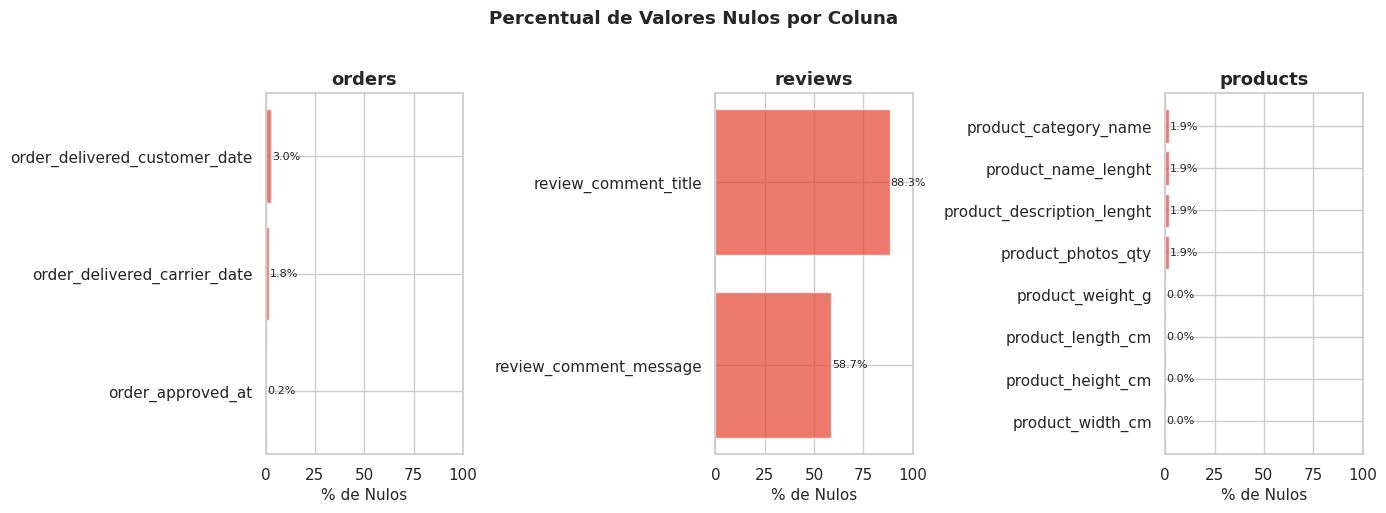

In [48]:
# ============================================================
# CÉLULA 2.4 — Heatmap visual de nulos
# ============================================================
# Visualização consolidada: para cada dataset, mostra
# o percentual de nulos por coluna em forma de gráfico de barras.
# Colunas sem nulos não aparecem.

datasets_com_nulos = {
    nome: df for nome, df in datasets.items()
    if df.isnull().sum().sum() > 0
}

if datasets_com_nulos:
    n_plots = len(datasets_com_nulos)
    fig, axes = plt.subplots(1, n_plots, figsize=(14, 5))
    if n_plots == 1:
        axes = [axes]

    for ax, (nome, df) in zip(axes, datasets_com_nulos.items()):
        pct_nulos = (df.isnull().sum() / len(df) * 100)
        pct_nulos = pct_nulos[pct_nulos > 0].sort_values(ascending=True)

        ax.barh(pct_nulos.index, pct_nulos.values, color='#e74c3c', alpha=0.75)
        ax.set_title(f'{nome}', fontweight='bold')
        ax.set_xlabel('% de Nulos')
        ax.set_xlim(0, 100)

        for i, v in enumerate(pct_nulos.values):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

    plt.suptitle('Percentual de Valores Nulos por Coluna', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


### 📌 O que aprendemos — Qualidade dos Dados

**Problema 1 — Datas como texto (`object`):**
Todas as colunas de data foram lidas como `object` (string).
Isso impede qualquer cálculo de tempo. Precisaremos de `pd.to_datetime()` sempre que trabalharmos com datas.

**Problema 2 — Nulos com significado de negócio:**
- `orders` → campos de entrega nulos: pedidos cancelados ou em trânsito (faz sentido não ter data de entrega)
- `reviews` → título e mensagem opcionais: cliente avaliou com nota mas não escreveu texto
- `products` → alguns sem categoria: produtos que os lojistas não classificaram corretamente

**Problema 3 — Sem duplicatas:**
Boa notícia! Nenhuma tabela tem linhas completamente repetidas. As chaves de junção parecem íntegras.

> 🎯 **Lição:** Nulos não são sempre erros — às vezes são a informação em si.
> Antes de usar `dropna()` ou `fillna()`, entenda o contexto de negócio.


---
## 📦 Seção 3 — Análise de Pedidos

A tabela `orders` é o **coração** do dataset. Ela registra o ciclo de vida completo de cada pedido:
da compra até a entrega ao cliente.

**Colunas principais:**
- `order_id` → identificador único do pedido
- `customer_id` → ID do comprador (há um detalhe aqui — veja Seção 4)
- `order_status` → fase atual do pedido
- `order_purchase_timestamp` → data/hora da compra
- `order_estimated_delivery_date` → prazo prometido
- `order_delivered_customer_date` → data real de entrega

**Perguntas que vamos responder:**
- Qual o volume de pedidos ao longo do tempo? Existe crescimento?
- Há sazonalidade (picos em determinados meses)?
- Qual o status da maioria dos pedidos?


In [49]:
# ============================================================
# CÉLULA 3.1 — Distribuição de status dos pedidos
# ============================================================
# 'order_status' indica a fase do pedido no momento do registro.
# value_counts() conta quantos pedidos há em cada status.

status_counts = df_orders['order_status'].value_counts()

print("📦 Distribuição de Status dos Pedidos")
print()
print(f"  {'Status':<25} {'Qtd':>9} {'% Total':>9}  Barra")
print("  " + "-"*65)

for status, count in status_counts.items():
    pct   = count / len(df_orders) * 100
    barra = '█' * int(pct / 2)
    print(f"  {status:<25} {count:>9,} {pct:>8.1f}%  {barra}")

print()
print(f"  Total de pedidos na base: {len(df_orders):,}")


📦 Distribuição de Status dos Pedidos

  Status                          Qtd   % Total  Barra
  -----------------------------------------------------------------
  delivered                    96,478     97.0%  ████████████████████████████████████████████████
  shipped                       1,107      1.1%  
  canceled                        625      0.6%  
  unavailable                     609      0.6%  
  invoiced                        314      0.3%  
  processing                      301      0.3%  
  created                           5      0.0%  
  approved                          2      0.0%  

  Total de pedidos na base: 99,441


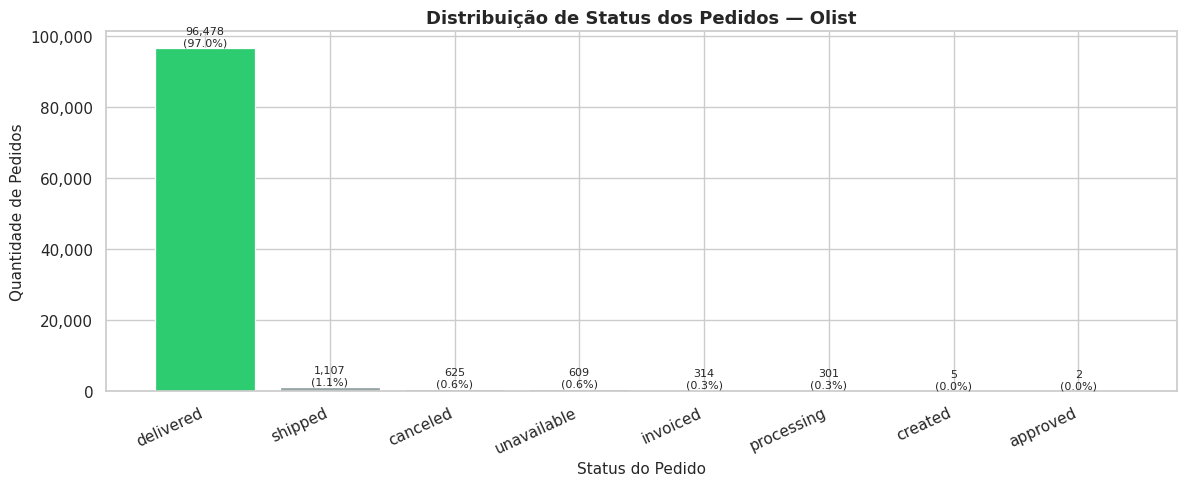


💡 97.0% dos pedidos foram entregues com sucesso.
   O restante está cancelado, em trânsito ou com problemas.


In [50]:
# ============================================================
# CÉLULA 3.2 — Gráfico: distribuição de status
# ============================================================

cores = ['#2ecc71' if s == 'delivered' else '#95a5a6'
         for s in status_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(status_counts.index, status_counts.values,
              color=cores, edgecolor='white', linewidth=0.9)

# Rótulo de valor + percentual acima de cada barra
for bar in bars:
    h   = bar.get_height()
    pct = h / len(df_orders) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 150,
            f'{h:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

ax.set_title('Distribuição de Status dos Pedidos — Olist', fontweight='bold')
ax.set_xlabel('Status do Pedido')
ax.set_ylabel('Quantidade de Pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

pct_del = status_counts.get('delivered', 0) / len(df_orders) * 100
print(f"\n💡 {pct_del:.1f}% dos pedidos foram entregues com sucesso.")
print("   O restante está cancelado, em trânsito ou com problemas.")


In [51]:
# ============================================================
# CÉLULA 3.3 — Conversão de datas e volume mensal
# ============================================================
# pd.to_datetime() converte o texto "2017-11-05 13:25:00"
# para o tipo datetime64, que permite cálculos temporais.
#
# .dt.to_period('M') → extrai o período mensal (ex: '2017-11')
# groupby + size     → conta pedidos por mês

# Converte a coluna de data de compra de texto para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(
    df_orders['order_purchase_timestamp']
)

# Extrai o período mensal de cada pedido
df_orders['ano_mes'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# Filtra apenas pedidos entregues para uma análise mais limpa
df_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

# Conta pedidos por mês e converte Period → string para o gráfico
monthly = (
    df_delivered
    .groupby('ano_mes')
    .size()
    .reset_index(name='pedidos')
)
monthly['mes_str'] = monthly['ano_mes'].astype(str)

print(f"📅 Período dos dados: {monthly['mes_str'].iloc[0]} → {monthly['mes_str'].iloc[-1]}")
print(f"   Meses com dados  : {len(monthly)}")
print()
print("Top 5 meses com mais pedidos entregues:")
print(monthly.nlargest(5, 'pedidos')[['mes_str','pedidos']].to_string(index=False))


📅 Período dos dados: 2016-09 → 2018-08
   Meses com dados  : 23

Top 5 meses com mais pedidos entregues:
mes_str  pedidos
2017-11     7289
2018-01     7069
2018-03     7003
2018-04     6798
2018-05     6749


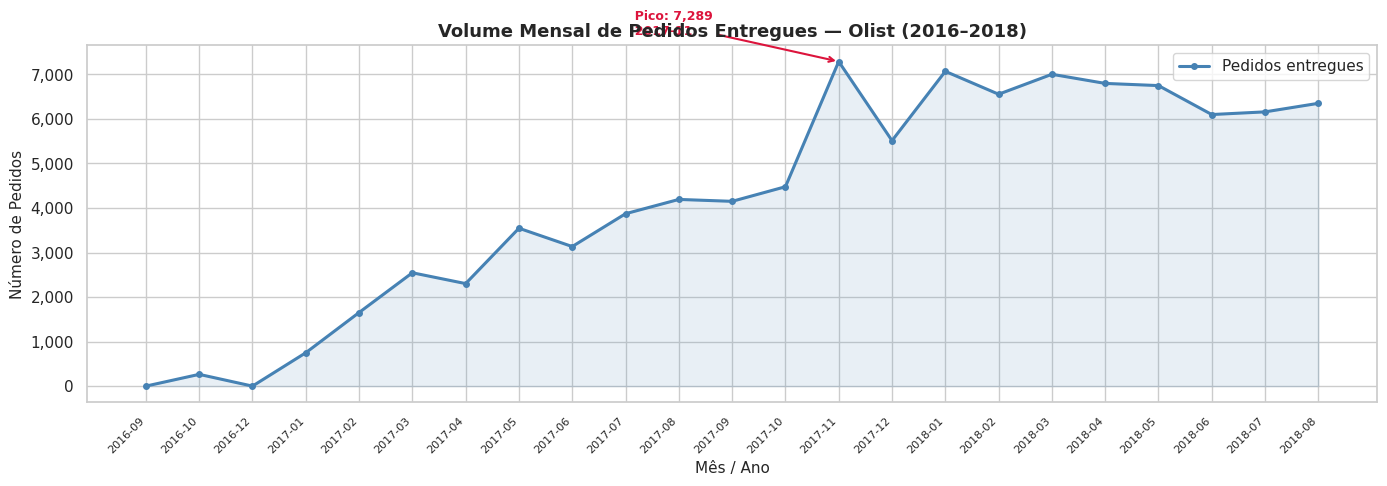

In [52]:
# ============================================================
# CÉLULA 3.4 — Gráfico: evolução mensal de pedidos
# ============================================================
# O gráfico de linha é ideal para mostrar tendência temporal.
# Adicionamos área sombreada e anotação do pico máximo.

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly['mes_str'],
    monthly['pedidos'],
    color='steelblue', linewidth=2.2,
    marker='o', markersize=4, label='Pedidos entregues'
)

# Área sombreada abaixo da linha (efeito visual de volume)
ax.fill_between(monthly['mes_str'], monthly['pedidos'],
                alpha=0.12, color='steelblue')

# Destaca o pico máximo com uma anotação em seta
idx_max = monthly['pedidos'].idxmax()
ax.annotate(
    f"  Pico: {monthly.loc[idx_max,'pedidos']:,}\n  {monthly.loc[idx_max,'mes_str']}",
    xy=(idx_max, monthly.loc[idx_max,'pedidos']),
    xytext=(idx_max - 4, monthly.loc[idx_max,'pedidos'] + 600),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
    color='crimson', fontsize=9, fontweight='bold'
)

ax.set_title('Volume Mensal de Pedidos Entregues — Olist (2016–2018)',
             fontweight='bold')
ax.set_xlabel('Mês / Ano')
ax.set_ylabel('Número de Pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


### 📌 O que aprendemos — Pedidos

- **Crescimento consistente:** O volume de pedidos cresce mês a mês, refletindo a expansão do e-commerce brasileiro entre 2016 e 2018.
- **2016 é incompleto:** Apenas os últimos meses de 2016 têm dados — a plataforma estava em fase de lançamento. Evite comparações anuais que incluam 2016 inteiro.
- **Pico em Nov/2017 → Black Friday!** O volume sobe bem acima da tendência nesse mês.
- **~97% dos pedidos foram entregues** (`delivered`). Os demais estão cancelados, em trânsito ou com problemas sistêmicos.
- **Sazonalidade:** Meses de fim de ano (Nov/Dez) tendem a ter picos — comportamento típico do varejo.

> 🔎 **Para investigar nas tarefas:** Como o tempo de entrega varia entre os estados?
> Existe relação entre o tempo de entrega e a nota de avaliação dada pelo cliente?


---
## 👥 Seção 4 — Análise de Clientes

A tabela `customers` contém informações demográficas dos compradores.
Mas ela guarda um **detalhe crítico** que já enganou diretores de marketing:
há **duas colunas de ID de cliente** com significados completamente diferentes!

**Perguntas que vamos responder:**
- Onde estão localizados os clientes? (Distribuição geográfica)
- Qual a diferença real entre `customer_id` e `customer_unique_id`?
- Quantos clientes compraram mais de uma vez?


In [53]:
# ============================================================
# CÉLULA 4.1 — Estrutura da tabela de clientes
# ============================================================
# .info() mostra: dtype, total de não-nulos, uso de memória
# .head() mostra as primeiras linhas com valores reais

print("📋 Estrutura da tabela CUSTOMERS:")
df_customers.info()
print()
print("Primeiras 3 linhas:")
display(df_customers.head(3))


📋 Estrutura da tabela CUSTOMERS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Primeiras 3 linhas:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [54]:
# ============================================================
# CÉLULA 4.2 — O paradoxo das duas chaves de cliente
# ============================================================
# customer_id      → ID da TRANSAÇÃO (sessão de compra)
#                    Muda a cada novo pedido do mesmo cliente!
#
# customer_unique_id → ID PERMANENTE do cliente
#                      Equivale ao CPF / login na plataforma
#
# Consequência: um cliente que comprou 3 vezes terá
#   → 3 customer_ids diferentes (um por pedido)
#   → sempre o mesmo customer_unique_id

n_cust_id     = df_customers['customer_id'].nunique()
n_cust_unique = df_customers['customer_unique_id'].nunique()
n_recorrentes = n_cust_id - n_cust_unique

print("=" * 60)
print("O PARADOXO DO customer_id")
print("=" * 60)
print()
print(f"  Total de linhas na tabela       : {len(df_customers):>10,}")
print(f"  customer_id únicos              : {n_cust_id:>10,}  ← ID de sessão (por compra)")
print(f"  customer_unique_id únicos       : {n_cust_unique:>10,}  ← ID real do cliente")
print()
print(f"  Diferença                       : {n_recorrentes:>10,}")
print(f"  → clientes que compraram MAIS DE UMA VEZ!")
print()
pct_ret = n_recorrentes / n_cust_unique * 100
print(f"  Taxa de retenção real           : {pct_ret:>10.2f}%")
print()
print("⚠️  ERRO CLÁSSICO: usar customer_id para contar clientes únicos")
print("   faz parecer que TODOS compraram apenas uma vez!")
print("   Use SEMPRE customer_unique_id para identificar pessoas reais.")


O PARADOXO DO customer_id

  Total de linhas na tabela       :     99,441
  customer_id únicos              :     99,441  ← ID de sessão (por compra)
  customer_unique_id únicos       :     96,096  ← ID real do cliente

  Diferença                       :      3,345
  → clientes que compraram MAIS DE UMA VEZ!

  Taxa de retenção real           :       3.48%

⚠️  ERRO CLÁSSICO: usar customer_id para contar clientes únicos
   faz parecer que TODOS compraram apenas uma vez!
   Use SEMPRE customer_unique_id para identificar pessoas reais.


In [55]:
# ============================================================
# CÉLULA 4.3 — Frequência de compras por cliente único
# ============================================================
# Para saber quantas compras cada cliente fez, precisamos:
# 1. Juntar orders com customers (para obter customer_unique_id)
# 2. Contar pedidos por customer_unique_id
# 3. Analisar a distribuição dessa contagem

# Merge: orders + customers (para ter o ID único)
df_oc = df_orders.merge(
    df_customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Conta pedidos por cliente único
pedidos_por_cliente = (
    df_oc.groupby('customer_unique_id')['order_id']
    .count()
    .rename('n_pedidos')
)

# Distribuição: quantos clientes fizeram X compras?
dist = pedidos_por_cliente.value_counts().sort_index()

print("📊 Distribuição de Compras por Cliente")
print()
print(f"  {'Nº Compras':<15} {'Clientes':>10} {'% do Total':>12}  Barra visual")
print("  " + "-"*65)

for n_comp, n_cli in dist.items():
    pct   = n_cli / n_cust_unique * 100
    barra = '█' * max(1, int(pct / 3))
    print(f"  {n_comp:<15} {n_cli:>10,} {pct:>11.1f}%  {barra}")


📊 Distribuição de Compras por Cliente

  Nº Compras        Clientes   % do Total  Barra visual
  -----------------------------------------------------------------
  1                   93,099        96.9%  ████████████████████████████████
  2                    2,745         2.9%  █
  3                      203         0.2%  █
  4                       30         0.0%  █
  5                        8         0.0%  █
  6                        6         0.0%  █
  7                        3         0.0%  █
  9                        1         0.0%  █
  17                       1         0.0%  █


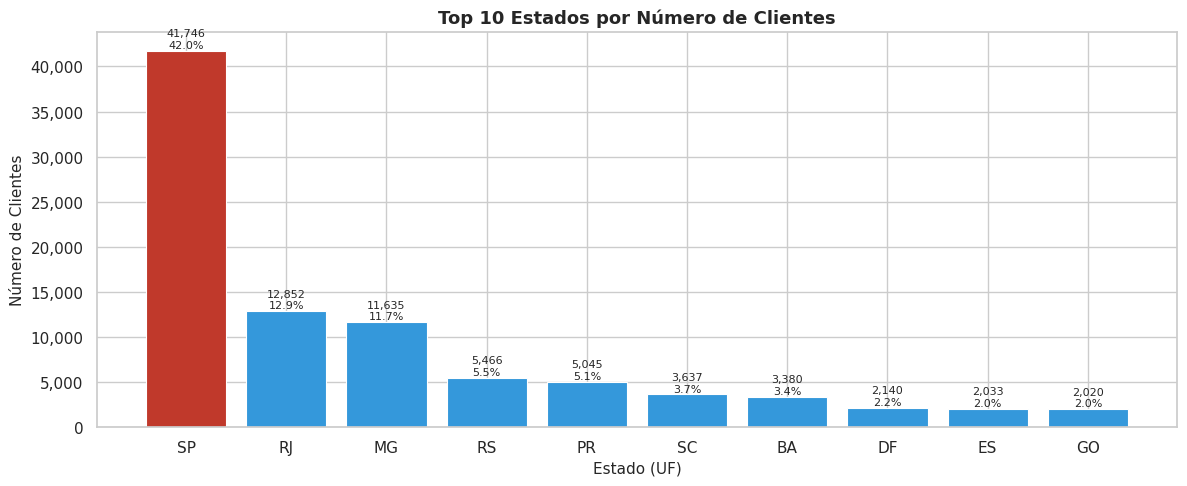


💡 São Paulo: 41,746 clientes (42.0% do total nacional)
   As 3 maiores UFs juntas representam mais de 60% da base.


In [56]:
# ============================================================
# CÉLULA 4.4 — Distribuição geográfica: clientes por estado
# ============================================================
# value_counts() conta e ordena do mais frequente ao menos frequente.
# head(10) pega apenas os 10 estados com mais clientes.

top_estados = df_customers['customer_state'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))

# SP em vermelho (sede da Olist), outros em azul
cores = ['#c0392b' if s == 'SP' else '#3498db' for s in top_estados.index]
bars  = ax.bar(top_estados.index, top_estados.values,
               color=cores, edgecolor='white', linewidth=0.8)

# Adiciona valor e % acima de cada barra
for bar in bars:
    h   = bar.get_height()
    pct = h / len(df_customers) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 100,
            f'{h:,}\n{pct:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Top 10 Estados por Número de Clientes', fontweight='bold')
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Número de Clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

pct_sp = top_estados['SP'] / len(df_customers) * 100
print(f"\n💡 São Paulo: {top_estados['SP']:,} clientes ({pct_sp:.1f}% do total nacional)")
print(f"   As 3 maiores UFs juntas representam mais de 60% da base.")


### 📌 O que aprendemos — Clientes

- **`customer_id` ≠ cliente real.** É um ID de transação que muda a cada pedido. Nunca use-o para contar clientes únicos ou calcular retenção.
- **`customer_unique_id`** é o identificador permanente do comprador — equivale ao CPF/login. Use sempre este para análises de comportamento.
- **~97% comprou apenas uma vez.** A taxa de retenção real é baixa (~3%), mas existem milhares de clientes recorrentes para campanhas de fidelização.
- **São Paulo domina com ~42% dos clientes,** seguido por RJ (~13%) e MG (~12%). O mercado é muito concentrado no Sudeste.
- **Oportunidade geográfica:** estados do Nordeste (BA, CE, PE) aparecem com volume crescente mas ainda pequeno.

> 🎯 **Impacto de negócio:** O CAC (Custo de Aquisição de Clientes) calculado com `customer_id`
> está **errado** — subestima o custo real porque infla o número de "novos" clientes.


---
## 📦 Seção 5 — Análise de Produtos

A tabela `products` descreve os itens vendidos na plataforma.
Os **preços de venda**, porém, estão em `order_items` — junto com o valor do frete por item.

**Perguntas que vamos responder:**
- Quais categorias têm mais produtos cadastrados?
- Qual a distribuição de preços dos itens vendidos?
- Existem produtos com preço muito acima da média (outliers)?
- Como se distribuem as dimensões físicas (peso, tamanho)?


In [57]:
# ============================================================
# CÉLULA 5.1 — Merge: produtos com tradução de categoria
# ============================================================
# As categorias estão em português ('cama_mesa_banho').
# A tabela 'translation' converte para inglês.
#
# how='left' → mantém todos os produtos, mesmo sem tradução.
# Produtos sem categoria traduzida ficam com NaN na coluna inglesa.

df_prod = df_products.merge(
    df_translate,
    on='product_category_name',
    how='left'
)

# Resumo do merge
n_cat    = df_prod['product_category_name_english'].nunique()
n_sem    = df_prod['product_category_name_english'].isnull().sum()

print(f"Total de produtos      : {len(df_prod):,}")
print(f"Categorias únicas (EN) : {n_cat}")
print(f"Sem categoria mapeada  : {n_sem} ({n_sem/len(df_prod)*100:.1f}%)")
print()
print("Categorias em português e suas traduções:")
display(df_translate.head(10))


Total de produtos      : 32,951
Categorias únicas (EN) : 71
Sem categoria mapeada  : 623 (1.9%)

Categorias em português e suas traduções:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


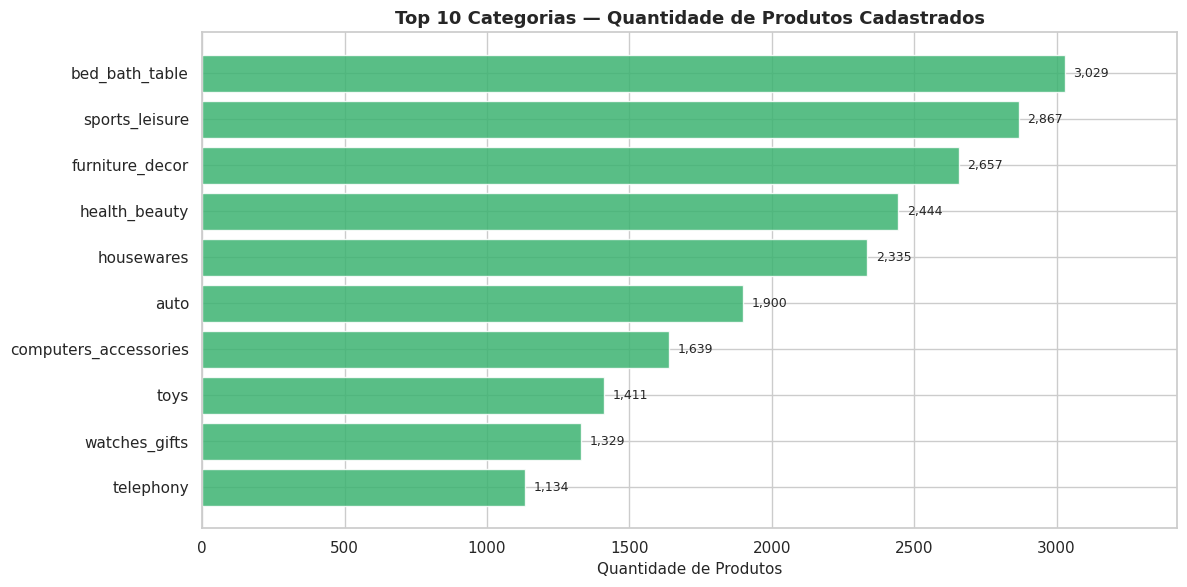

In [58]:
# ============================================================
# CÉLULA 5.2 — Top 10 categorias por quantidade de produtos
# ============================================================
# value_counts() conta e ordena do maior para o menor.
# O gráfico horizontal (barh) é melhor para rótulos longos.

top_cat = (
    df_prod['product_category_name_english']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))

# Reverte a ordem para o maior aparecer no topo
bars = ax.barh(top_cat.index[::-1], top_cat.values[::-1],
               color='mediumseagreen', edgecolor='white', alpha=0.85)

# Valor ao lado direito de cada barra
for bar in bars:
    w = bar.get_width()
    ax.text(w + 30, bar.get_y() + bar.get_height()/2,
            f'{w:,}', va='center', fontsize=9)

ax.set_title('Top 10 Categorias — Quantidade de Produtos Cadastrados',
             fontweight='bold')
ax.set_xlabel('Quantidade de Produtos')
ax.set_xlim(0, top_cat.values.max() * 1.13)
plt.tight_layout()
plt.show()


In [59]:
# ============================================================
# CÉLULA 5.3 — Distribuição de preços (via order_items)
# ============================================================
# Os preços de venda estão em df_items['price'].
# .describe() exibe as principais estatísticas descritivas.
#
# Interpretar:
#   Mediana < Média → distribuição assimétrica (outliers altos)
#   IQR = Q3 - Q1  → onde 50% dos preços se concentram

stats = df_items['price'].describe()

print("💰 Estatísticas de Preço (por item vendido)")
print()
print(f"  {'Contagem':<18}: {stats['count']:>10,.0f} itens")
print(f"  {'Mínimo':<18}: R$ {stats['min']:>10,.2f}")
print(f"  {'1º Quartil (Q1)':<18}: R$ {stats['25%']:>10,.2f}")
print(f"  {'Mediana (Q2)':<18}: R$ {stats['50%']:>10,.2f}  ← metade custa menos que isso")
print(f"  {'Média':<18}: R$ {stats['mean']:>10,.2f}  ← puxada pelos caros (acima da mediana!)")
print(f"  {'3º Quartil (Q3)':<18}: R$ {stats['75%']:>10,.2f}")
print(f"  {'Máximo':<18}: R$ {stats['max']:>10,.2f}  ← possível outlier extremo")
print()
iqr = stats['75%'] - stats['25%']
print(f"  IQR (Q3 - Q1)     : R$ {iqr:>10,.2f}  ← amplitude do 'meio' dos dados")
print(f"  Desvio Padrão     : R$ {df_items['price'].std():>10,.2f}")


💰 Estatísticas de Preço (por item vendido)

  Contagem          :    112,650 itens
  Mínimo            : R$       0.85
  1º Quartil (Q1)   : R$      39.90
  Mediana (Q2)      : R$      74.99  ← metade custa menos que isso
  Média             : R$     120.65  ← puxada pelos caros (acima da mediana!)
  3º Quartil (Q3)   : R$     134.90
  Máximo            : R$   6,735.00  ← possível outlier extremo

  IQR (Q3 - Q1)     : R$      95.00  ← amplitude do 'meio' dos dados
  Desvio Padrão     : R$     183.63


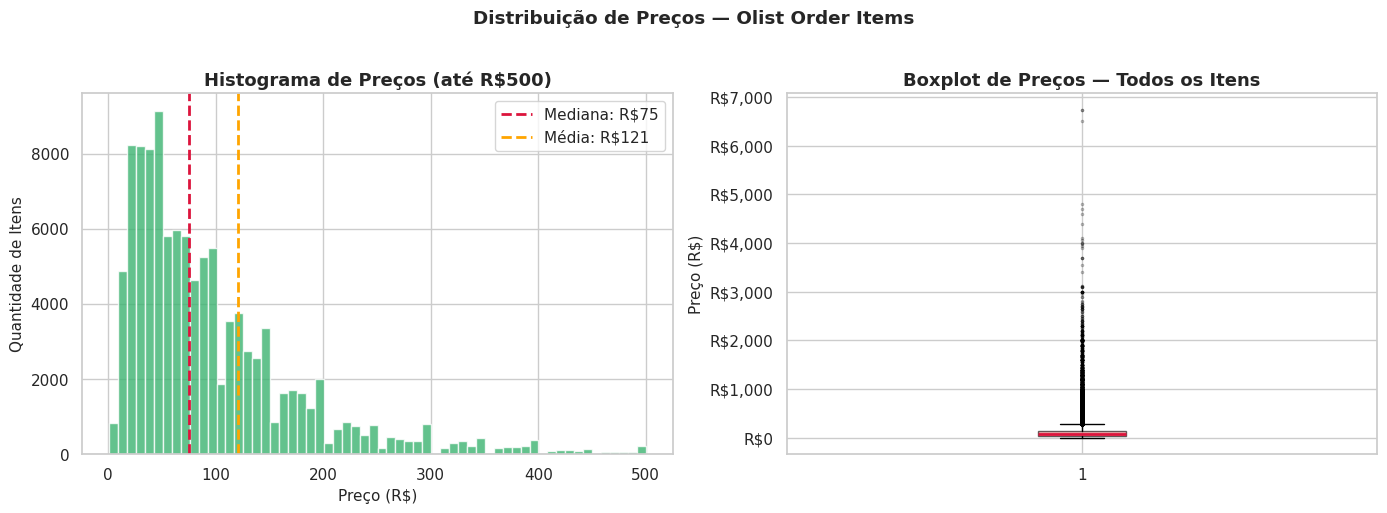


⚠️  Produtos acima de R$500: 3,216 (2.9% dos itens)


In [60]:
# ============================================================
# CÉLULA 5.4 — Histograma e boxplot de preços
# ============================================================
# Histograma: mostra a forma da distribuição de frequências
# Boxplot: destaca mediana, quartis e outliers (pontos além dos whiskers)
#
# Filtramos precos <= 500 no histograma para visualizar
# onde a maioria dos produtos está. O boxplot usa todos.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma (preços até R$500) ───────────────────────────
preco_filtrado = df_items[df_items['price'] <= 500]['price']
axes[0].hist(preco_filtrado, bins=60, color='mediumseagreen',
             edgecolor='white', alpha=0.8)

# Linha vertical na mediana
mediana = df_items['price'].median()
axes[0].axvline(mediana, color='crimson', linestyle='--', linewidth=2,
                label=f'Mediana: R${mediana:.0f}')
axes[0].axvline(df_items['price'].mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Média: R${df_items["price"].mean():.0f}')

axes[0].set_title('Histograma de Preços (até R$500)', fontweight='bold')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Quantidade de Itens')
axes[0].legend()

# ── Boxplot (todos os preços) ────────────────────────────────
axes[1].boxplot(df_items['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.6),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))

axes[1].set_title('Boxplot de Preços — Todos os Itens', fontweight='bold')
axes[1].set_ylabel('Preço (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.suptitle('Distribuição de Preços — Olist Order Items', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_out = (df_items['price'] > 500).sum()
print(f"\n⚠️  Produtos acima de R$500: {n_out:,} ({n_out/len(df_items)*100:.1f}% dos itens)")


### 📌 O que aprendemos — Produtos

- **Cama/Mesa/Banho lidera em volume** de produtos cadastrados, seguida por Esporte/Lazer e Moveis/Decoração.
- **Distribuição de preços assimétrica à direita:** a mediana (~R$74) é bem menor que a média (~R$120) — confirmando outliers de alto valor.
- **Outliers extremos existem:** produtos acima de R$500 representam uma minoria, mas puxam a média para cima significativamente.
- **IQR do preço:** 50% dos produtos custam entre R$30 e R$135 — o núcleo "popular" do marketplace.
- O **boxplot** revela muitos pontos além do whisker superior → cauda longa típica de marketplace com produtos variados.

> 💡 **Dica técnica:** Quando mediana e média diferem muito, prefira a **mediana** como medida central.
> Ela é resistente a outliers. A média pode ser enganosa em distribuições assimétricas.


---
## 💳 Seção 6 — Análise de Pagamentos

A tabela `payments` registra **como** cada pedido foi pago.
Um pedido pode ter **múltiplas linhas** de pagamento — por exemplo, quando o cliente usa cartão de crédito mais um vale-presente.

**Perguntas que vamos responder:**
- Qual a forma de pagamento mais usada?
- Qual o ticket médio por tipo de pagamento?
- Como é a distribuição do número de parcelas no cartão?
- Qual o impacto dos pagamentos parcelados no volume total?


In [61]:
# ============================================================
# CÉLULA 6.1 — Resumo por tipo de pagamento
# ============================================================

pay_counts = df_payments['payment_type'].value_counts()
pay_total  = df_payments.groupby('payment_type')['payment_value'].sum()
pay_mean   = df_payments.groupby('payment_type')['payment_value'].mean()

print("💳 Análise por Tipo de Pagamento")
print()
print(f"  {'Tipo':<20} {'Transações':>12} {'% Vol':>7}  {'Ticket Médio':>14}  {'Total R$':>15}")
print("  " + "-"*75)

for tipo in pay_counts.index:
    n   = pay_counts[tipo]
    pct = n / pay_counts.sum() * 100
    tkt = pay_mean.get(tipo, 0)
    tot = pay_total.get(tipo, 0)
    print(f"  {tipo:<20} {n:>12,} {pct:>6.1f}%  R$ {tkt:>11,.2f}  R$ {tot:>13,.2f}")

print()
print(f"  Total geral: R$ {df_payments['payment_value'].sum():,.2f}")


💳 Análise por Tipo de Pagamento

  Tipo                   Transações   % Vol    Ticket Médio         Total R$
  ---------------------------------------------------------------------------
  credit_card                76,795   73.9%  R$      163.32  R$ 12,542,084.19
  boleto                     19,784   19.0%  R$      145.03  R$  2,869,361.27
  voucher                     5,775    5.6%  R$       65.70  R$    379,436.87
  debit_card                  1,529    1.5%  R$      142.57  R$    217,989.79
  not_defined                     3    0.0%  R$        0.00  R$          0.00

  Total geral: R$ 16,008,872.12


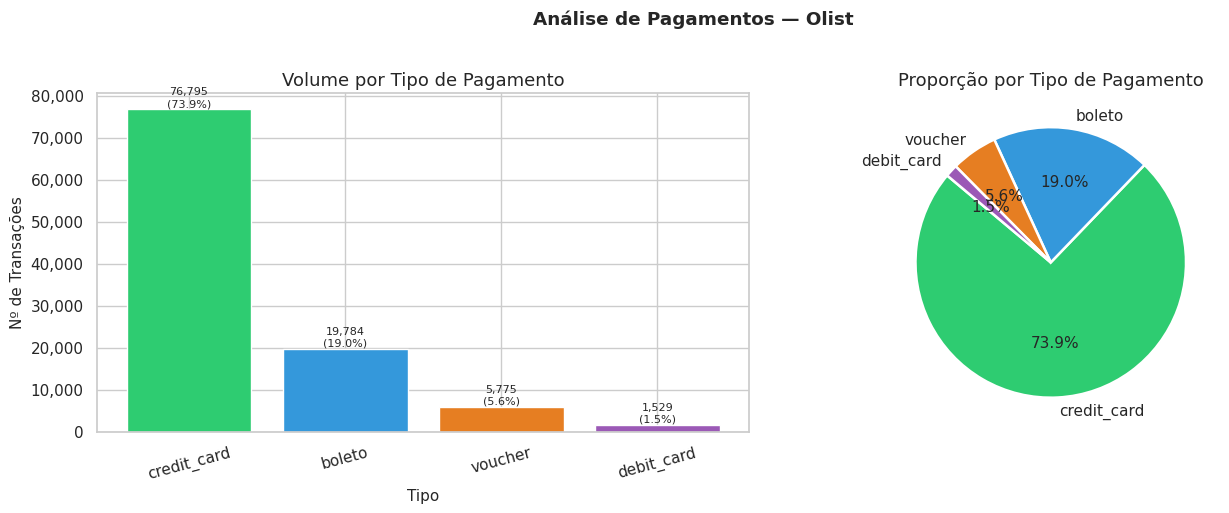

In [62]:
# ============================================================
# CÉLULA 6.2 — Gráfico: tipo de pagamento (volume e proporção)
# ============================================================

# Remove 'not_defined' para limpar a visualização
pay_plot = pay_counts[pay_counts.index != 'not_defined']

color_map = {
    'credit_card' : '#2ecc71',
    'boleto'      : '#3498db',
    'voucher'     : '#e67e22',
    'debit_card'  : '#9b59b6',
}
cores = [color_map.get(t, '#95a5a6') for t in pay_plot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barras: volume de transações ────────────────────────────
bars = axes[0].bar(pay_plot.index, pay_plot.values,
                   color=cores, edgecolor='white', linewidth=1)
for bar in bars:
    h   = bar.get_height()
    pct = h / pay_plot.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 200,
                 f'{h:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

axes[0].set_title('Volume por Tipo de Pagamento')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Nº de Transações')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=15)

# ── Pizza: proporção relativa ────────────────────────────────
axes[1].pie(
    pay_plot.values,
    labels=pay_plot.index,
    autopct='%1.1f%%',
    colors=cores,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.8)
)
axes[1].set_title('Proporção por Tipo de Pagamento')

plt.suptitle('Análise de Pagamentos — Olist', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


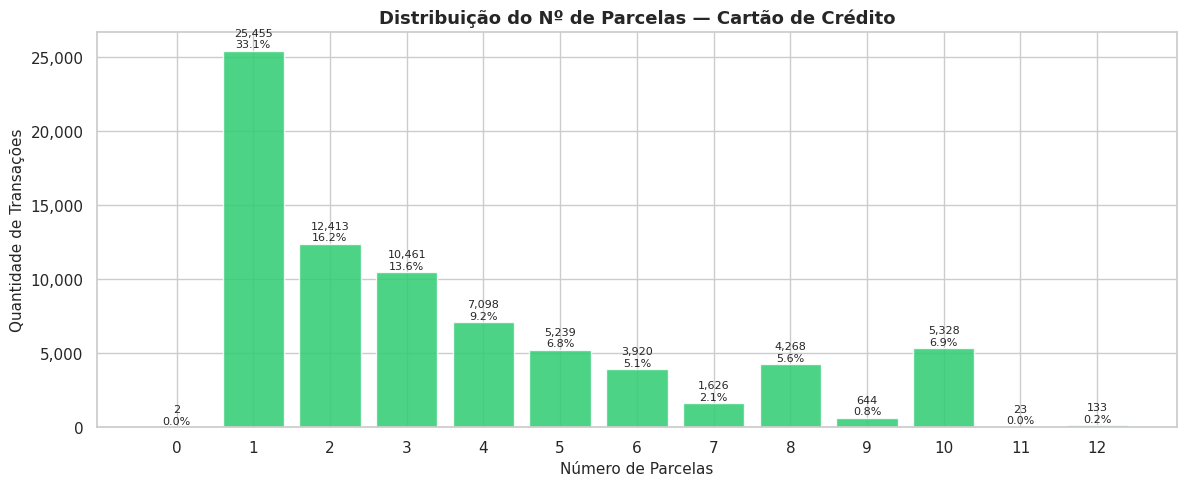


💡 Parcelas no cartão — Média: 3.5x | Mediana: 3x
   33.1% das compras no cartão são à vista (1x)


In [63]:
# ============================================================
# CÉLULA 6.3 — Distribuição de parcelas (cartão de crédito)
# ============================================================
# Apenas cartão de crédito usa parcelas de forma significativa.
# Analisamos como os clientes preferem dividir suas compras.

df_cc = df_payments[df_payments['payment_type'] == 'credit_card'].copy()

parcelas = df_cc['payment_installments'].value_counts().sort_index().head(13)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(parcelas.index.astype(str), parcelas.values,
              color='#2ecc71', edgecolor='white', alpha=0.85)

for bar in bars:
    h   = bar.get_height()
    pct = h / len(df_cc) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 100,
            f'{h:,}\n{pct:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Distribuição do Nº de Parcelas — Cartão de Crédito', fontweight='bold')
ax.set_xlabel('Número de Parcelas')
ax.set_ylabel('Quantidade de Transações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

media_parc = df_cc['payment_installments'].mean()
mediana_parc = df_cc['payment_installments'].median()
print(f"\n💡 Parcelas no cartão — Média: {media_parc:.1f}x | Mediana: {mediana_parc:.0f}x")
print(f"   {(df_cc['payment_installments']==1).sum()/len(df_cc)*100:.1f}% das compras no cartão são à vista (1x)")


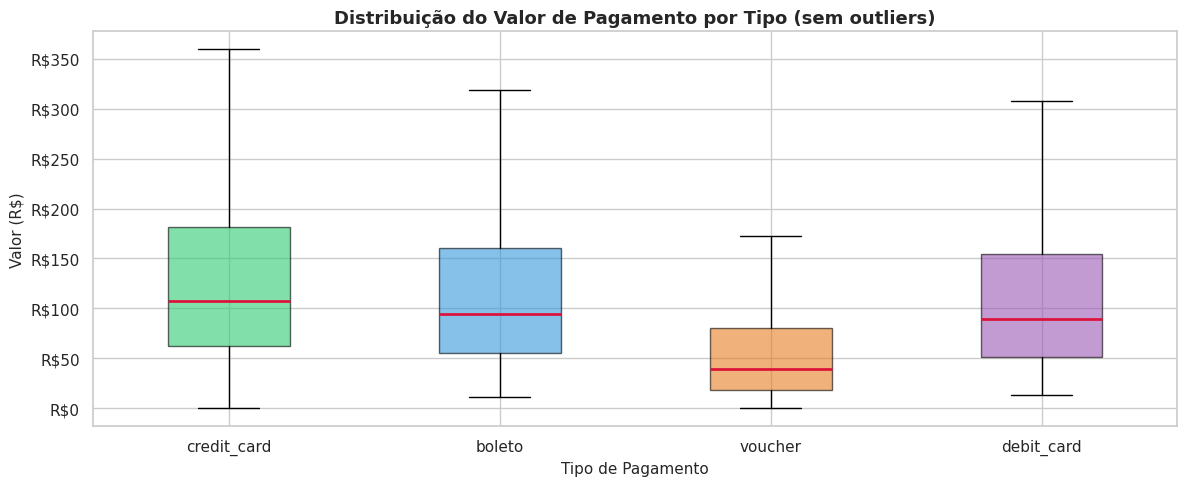

In [64]:
# ============================================================
# CÉLULA 6.4 — Ticket médio por tipo de pagamento (boxplot)
# ============================================================
# O boxplot compara as distribuições de valor entre tipos.
# Isso é mais informativo que apenas a média.

df_pay_plot = df_payments[df_payments['payment_type'].isin(
    ['credit_card', 'boleto', 'voucher', 'debit_card']
)].copy()

fig, ax = plt.subplots(figsize=(12, 5))

tipos    = df_pay_plot['payment_type'].unique()
dados    = [df_pay_plot[df_pay_plot['payment_type'] == t]['payment_value'].values for t in tipos]
cores_bp = [color_map.get(t, '#95a5a6') for t in tipos]

bp = ax.boxplot(dados, labels=tipos, patch_artist=True, showfliers=False)
for patch, cor in zip(bp['boxes'], cores_bp):
    patch.set_facecolor(cor)
    patch.set_alpha(0.6)

# Linha de mediana em vermelho
for med in bp['medians']:
    med.set(color='crimson', linewidth=2)

ax.set_title('Distribuição do Valor de Pagamento por Tipo (sem outliers)', fontweight='bold')
ax.set_xlabel('Tipo de Pagamento')
ax.set_ylabel('Valor (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
plt.tight_layout()
plt.show()


### 📌 O que aprendemos — Pagamentos

- **Cartão de crédito domina:** ~73% das transações — de longe o meio favorito dos brasileiros.
- **Boleto tem ticket médio mais alto:** compradores que optam por boleto tendem a fazer compras maiores (planejadas).
- **Parcelamento:** ~40% das compras no cartão são à vista (1x). Parcelas de 2x e 3x são as mais comuns entre quem divide.
- **Parcelamentos longos (8x–10x+) existem** — indicam produtos de ticket alto como eletrônicos.
- **Voucher representa menos de 6%** do volume — geralmente cupons de desconto de campanhas de marketing.

> 🎯 **Insight estratégico:** O parcelamento é uma **alavanca de conversão** no Brasil.
> Oferecer 10x sem juros pode aumentar o ticket médio — mas requer análise de custo financeiro para os vendedores.


---
## ⭐ Seção 7 — Análise de Avaliações

Os clientes avaliam os pedidos em uma escala de **1 a 5 estrelas**.
Esta é uma das métricas mais valiosas do dataset — reflete a **experiência completa de compra**:
produto, preço, comunicação e entrega.

**Perguntas que vamos responder:**
- Como se distribui as notas? Há polarização?
- Qual o percentual de avaliações positivas vs negativas?
- Quais categorias de produto têm as melhores e piores notas?
- Existe diferença de nota por estado do cliente?


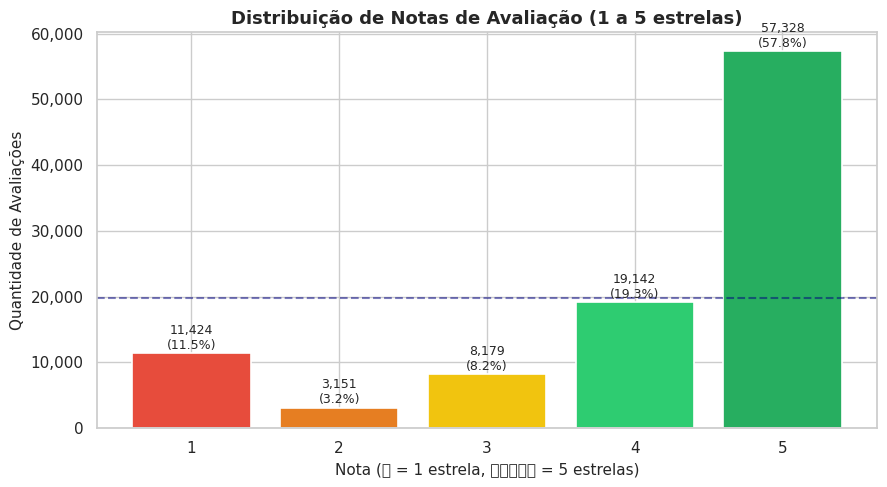


Nota média geral: 4.086 estrelas
Mediana         : 5.0 estrelas


In [65]:
# ============================================================
# CÉLULA 7.1 — Distribuição das notas de avaliação
# ============================================================
# review_score varia de 1 a 5 (estrelas).
# value_counts() + sort_index() garante a ordem 1, 2, 3, 4, 5.

score_counts = df_reviews['review_score'].value_counts().sort_index()

# Mapeamento de cores: vermelho = ruim, verde = bom
cores_score = {1:'#e74c3c', 2:'#e67e22', 3:'#f1c40f', 4:'#2ecc71', 5:'#27ae60'}

fig, ax = plt.subplots(figsize=(9, 5))

for score, count in score_counts.items():
    pct = count / len(df_reviews) * 100
    bar = ax.bar(str(score), count,
                 color=cores_score[score], edgecolor='white', linewidth=1.2)
    ax.text(str(score), count + 200,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Linha de média
ax.axhline(score_counts.mean(), color='navy', linestyle='--', alpha=0.5,
           label=f'Média de contagem')

ax.set_title('Distribuição de Notas de Avaliação (1 a 5 estrelas)', fontweight='bold')
ax.set_xlabel('Nota (⭐ = 1 estrela, ⭐⭐⭐⭐⭐ = 5 estrelas)')
ax.set_ylabel('Quantidade de Avaliações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"\nNota média geral: {df_reviews['review_score'].mean():.3f} estrelas")
print(f"Mediana         : {df_reviews['review_score'].median():.1f} estrelas")


⭐ Classificação de Sentimento das Avaliações

  👍 Positivas (4-5 estrelas) :   76,470  (77.1%)
  😐 Neutras   (3 estrelas)   :    8,179  (8.2%)
  👎 Negativas (1-2 estrelas) :   14,575  (14.7%)

  Total de avaliações         :   99,224


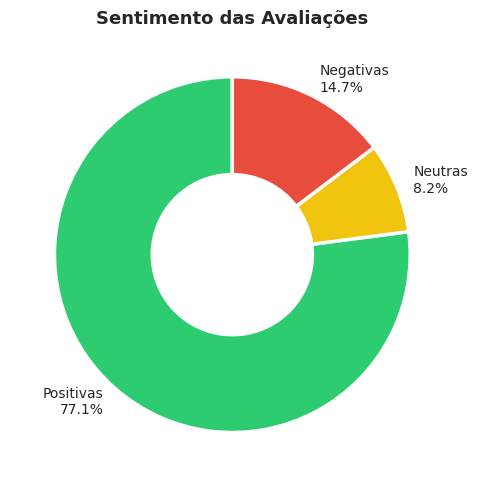

In [66]:
# ============================================================
# CÉLULA 7.2 — Classificação: Positivo / Neutro / Negativo
# ============================================================
# Classificação padrão em análise de satisfação (NPS adaptado):
#   1–2 estrelas → Negativa  (detratores)
#   3 estrelas   → Neutra    (passivos)
#   4–5 estrelas → Positiva  (promotores)

# Remove avaliações sem nota para não distorcer percentuais
df_rev_clean = df_reviews.dropna(subset=['review_score']).copy()
total = len(df_rev_clean)

pos = (df_rev_clean['review_score'] >= 4).sum()
neu = (df_rev_clean['review_score'] == 3).sum()
neg = (df_rev_clean['review_score'] <= 2).sum()

print("⭐ Classificação de Sentimento das Avaliações")
print()
print(f"  👍 Positivas (4-5 estrelas) : {pos:>8,}  ({pos/total*100:.1f}%)")
print(f"  😐 Neutras   (3 estrelas)   : {neu:>8,}  ({neu/total*100:.1f}%)")
print(f"  👎 Negativas (1-2 estrelas) : {neg:>8,}  ({neg/total*100:.1f}%)")
print()
print(f"  Total de avaliações         : {total:>8,}")

# Gráfico de rosca (donut)
fig, ax = plt.subplots(figsize=(7, 5))
sizes  = [pos, neu, neg]
labels = [f'Positivas\n{pos/total*100:.1f}%',
          f'Neutras\n{neu/total*100:.1f}%',
          f'Negativas\n{neg/total*100:.1f}%']
cores  = ['#2ecc71', '#f1c40f', '#e74c3c']

ax.pie(sizes, labels=labels, colors=cores, startangle=90,
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
       textprops=dict(fontsize=10))
ax.set_title('Sentimento das Avaliações', fontweight='bold')
plt.tight_layout()
plt.show()


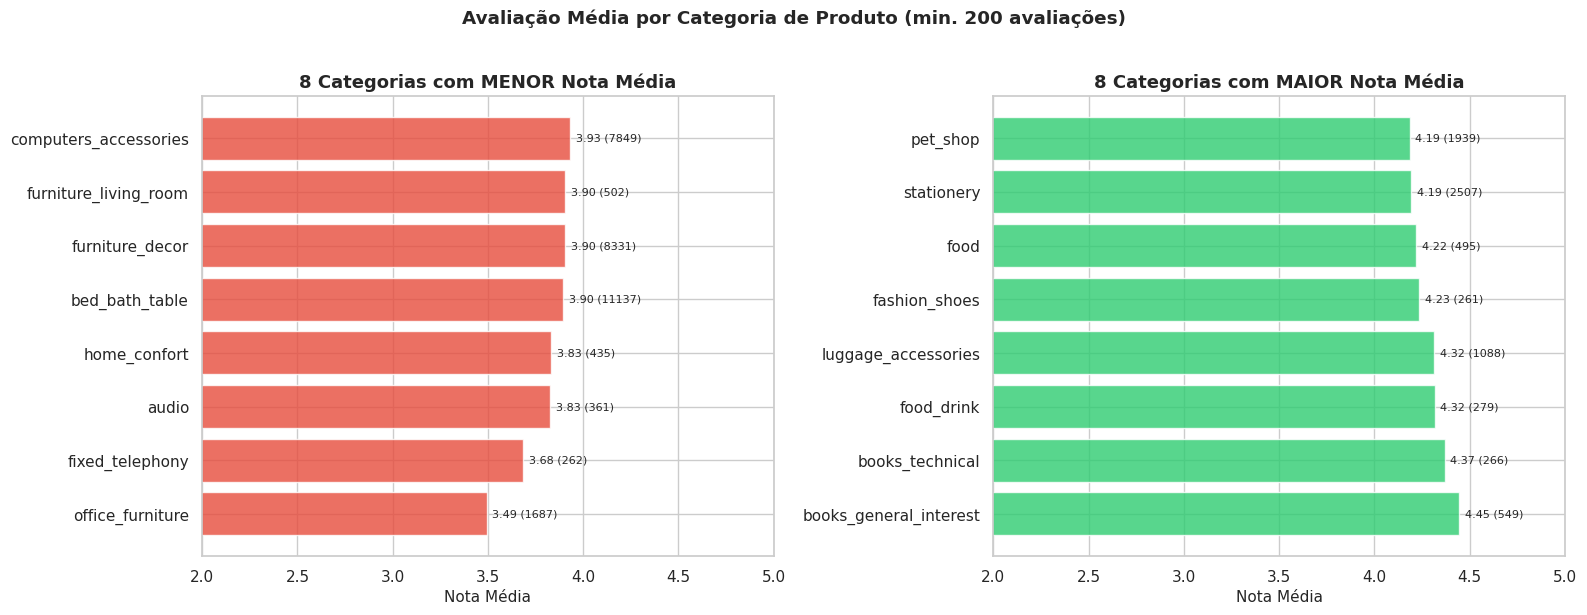

In [67]:
# ============================================================
# CÉLULA 7.3 — Nota média por categoria de produto
# ============================================================
# Para cruzar avaliações com categoria, precisamos de um
# caminho entre as tabelas:
#   reviews → orders → order_items → products (com tradução)
#
# Fazemos os merges em sequência:

# Passo 1: reviews + order_id de orders (garante que só temos pedidos válidos)
df_rv = df_reviews[['order_id','review_score']].merge(
    df_orders[['order_id']], on='order_id', how='inner'
)

# Passo 2: + items (para ter product_id)
df_rv = df_rv.merge(df_items[['order_id','product_id']], on='order_id', how='left')

# Passo 3: + produtos com categoria em inglês
df_rv = df_rv.merge(
    df_prod[['product_id','product_category_name_english']],
    on='product_id', how='left'
)

# Nota média por categoria (mínimo 200 avaliações para confiabilidade)
cat_score = (
    df_rv.groupby('product_category_name_english')['review_score']
    .agg(['mean','count'])
    .reset_index()
    .query('count >= 200')
    .sort_values('mean')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 10 piores ────────────────────────────────────────────────
piores = cat_score.head(8)
axes[0].barh(piores['product_category_name_english'],
             piores['mean'], color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('8 Categorias com MENOR Nota Média', fontweight='bold')
axes[0].set_xlabel('Nota Média')
axes[0].set_xlim(2.0, 5.0)
for _, row in piores.iterrows():
    axes[0].text(row['mean'] + 0.03,
                 list(piores['product_category_name_english']).index(row['product_category_name_english']),
                 f"{row['mean']:.2f} ({row['count']:.0f})", va='center', fontsize=8)

# ── 8 melhores ───────────────────────────────────────────────
melhores = cat_score.tail(8).iloc[::-1]
axes[1].barh(melhores['product_category_name_english'],
             melhores['mean'], color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('8 Categorias com MAIOR Nota Média', fontweight='bold')
axes[1].set_xlabel('Nota Média')
axes[1].set_xlim(2.0, 5.0)
for _, row in melhores.iterrows():
    axes[1].text(row['mean'] + 0.03,
                 list(melhores['product_category_name_english']).index(row['product_category_name_english']),
                 f"{row['mean']:.2f} ({row['count']:.0f})", va='center', fontsize=8)

plt.suptitle('Avaliação Média por Categoria de Produto (min. 200 avaliações)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📌 O que aprendemos — Avaliações

- **Distribuição polarizada:** Nota 5 é a mais frequente (~57%), mas nota 1 aparece em ~11% das avaliações. Clientes tendem a ser extremos — ou ficam muito satisfeitos ou muito insatisfeitos.
- **77% de avaliações positivas (4-5 estrelas):** O NPS geral da Olist é saudável, mas o volume de negativas é relevante para investigação.
- **Categorias de tecnologia e moda** tendem a receber notas mais baixas — provavelmente por desalinhamento entre expectativa e produto real, ou problemas de entrega.
- **Categorias de nicho** (instrumentos musicais, livros) têm notas altas — compradores com expectativas mais específicas e melhor atendidas.
- **Nota 3 ("neutra") é a menos comum** — confirmando a polarização típica de reviews online.

> 🔎 **Hipótese para investigar nas tarefas:** Pedidos com entrega acima do prazo estimado
> tendem a receber notas mais baixas? Há uma "quebra de nota" a partir de X dias de atraso?


---
## 🏪 Seção 8 — Análise de Vendedores

A tabela `sellers` descreve os lojistas parceiros que vendem pela plataforma Olist.
Comparar a distribuição de **vendedores** com a de **clientes** por estado revela
**gaps geográficos** — estados onde há muita demanda mas pouca oferta (e vice-versa).

**Perguntas que vamos responder:**
- Onde estão concentrados os vendedores?
- Como essa distribuição compara com a dos clientes?
- Quais estados têm mais clientes por vendedor (maior potencial de expansão)?


In [68]:
# ============================================================
# CÉLULA 8.1 — Vendedores por estado
# ============================================================

seller_state = df_sellers['seller_state'].value_counts()

print("🏪 Vendedores por Estado")
print()
print(f"  {'Estado':<8} {'Vendedores':>12} {'% do Total':>12}  Barra")
print("  " + "-"*55)

for estado, n in seller_state.items():
    pct   = n / len(df_sellers) * 100
    barra = '█' * max(1, int(pct / 2))
    print(f"  {estado:<8} {n:>12,} {pct:>11.1f}%  {barra}")

print()
print(f"  Total de vendedores: {len(df_sellers):,}")
print(f"  Estados com vendedores: {seller_state.shape[0]}")


🏪 Vendedores por Estado

  Estado     Vendedores   % do Total  Barra
  -------------------------------------------------------
  SP              1,849        59.7%  █████████████████████████████
  PR                349        11.3%  █████
  MG                244         7.9%  ███
  SC                190         6.1%  ███
  RJ                171         5.5%  ██
  RS                129         4.2%  ██
  GO                 40         1.3%  █
  DF                 30         1.0%  █
  ES                 23         0.7%  █
  BA                 19         0.6%  █
  CE                 13         0.4%  █
  PE                  9         0.3%  █
  PB                  6         0.2%  █
  MS                  5         0.2%  █
  RN                  5         0.2%  █
  MT                  4         0.1%  █
  RO                  2         0.1%  █
  SE                  2         0.1%  █
  AC                  1         0.0%  █
  PI                  1         0.0%  █
  MA                  1         0.0

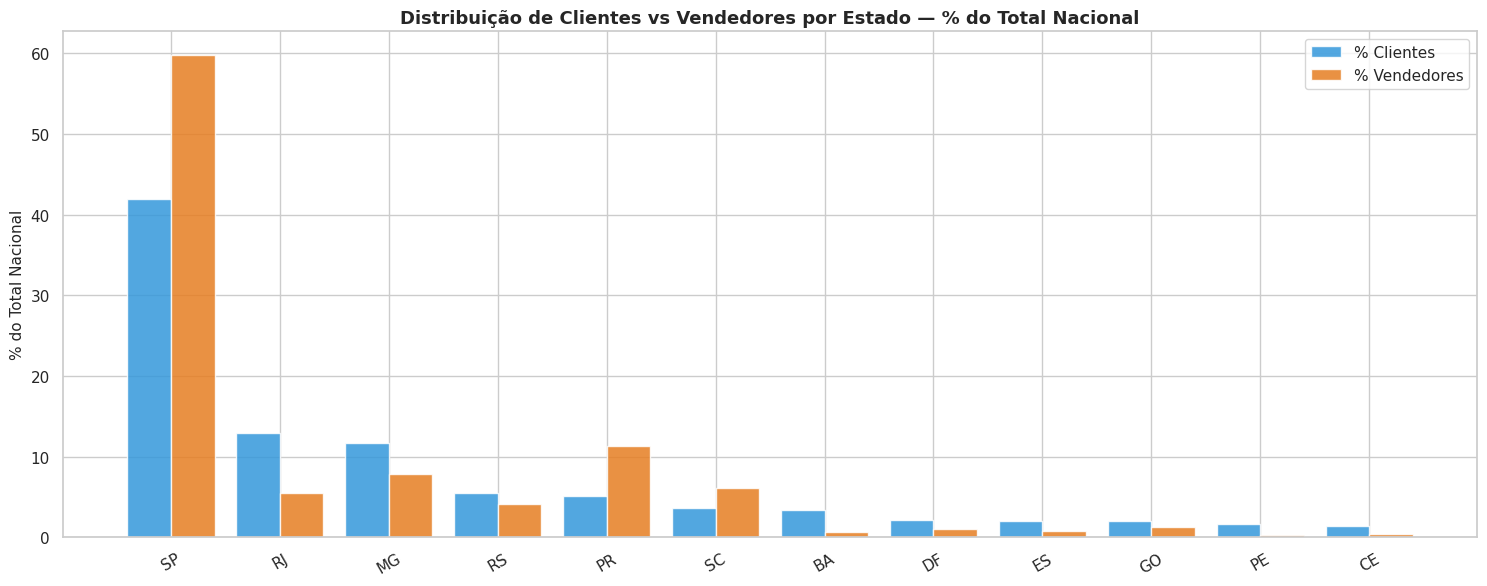

In [69]:
# ============================================================
# CÉLULA 8.2 — Mapa de cobertura: vendedores vs clientes
# ============================================================
# Criamos um DataFrame comparativo para identificar onde
# há mais clientes do que vendedores (gap de cobertura).
#
# Normalizamos os valores em percentual para comparar
# grandezas diferentes (3k vendedores vs 99k clientes).

# Percentual de clientes por estado
cust_pct = (
    df_customers['customer_state']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
    .rename(columns={'customer_state':'estado', 'proportion':'pct_clientes'})
)

# Percentual de vendedores por estado
sell_pct = (
    df_sellers['seller_state']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
    .rename(columns={'seller_state':'estado', 'proportion':'pct_vendedores'})
)

# Junta os dois percentuais
compare = cust_pct.merge(sell_pct, on='estado', how='outer').fillna(0)
compare = compare.sort_values('pct_clientes', ascending=False).head(12)

# Calcula o "gap": quanto mais alto, mais clientes por vendedor
compare['ratio_clientes_por_vendedor'] = (
    compare['pct_clientes'] / compare['pct_vendedores'].replace(0, 0.01)
).round(1)

# Gráfico de barras agrupadas
x     = range(len(compare))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar([i - width/2 for i in x], compare['pct_clientes'],
       width=width, label='% Clientes', color='#3498db', alpha=0.85, edgecolor='white')
ax.bar([i + width/2 for i in x], compare['pct_vendedores'],
       width=width, label='% Vendedores', color='#e67e22', alpha=0.85, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(compare['estado'], rotation=30)
ax.set_title('Distribuição de Clientes vs Vendedores por Estado — % do Total Nacional',
             fontweight='bold')
ax.set_ylabel('% do Total Nacional')
ax.legend()
plt.tight_layout()
plt.show()


In [70]:
# ============================================================
# CÉLULA 8.3 — Ranking: potencial de expansão por estado
# ============================================================
# O "ratio clientes/vendedor" indica onde a demanda supera a oferta.
# Estados com ratio alto = menos vendedores para atender os clientes.

print("📊 Potencial de Expansão: Ratio Clientes / Vendedor (% relativo)")
print()
print(f"  {'Estado':<8} {'% Clientes':>12} {'% Vendedores':>14} {'Ratio':>8}  Interpretação")
print("  " + "-"*75)

for _, row in compare.iterrows():
    r = row['ratio_clientes_por_vendedor']
    if r > 3:
        interp = "🔴 Alta demanda, poucos vendedores"
    elif r > 1.5:
        interp = "🟡 Demanda moderada acima da oferta"
    else:
        interp = "🟢 Bem coberto"

    print(f"  {row['estado']:<8} {row['pct_clientes']:>11.1f}% {row['pct_vendedores']:>13.1f}% "
          f"{r:>7.1f}x  {interp}")


📊 Potencial de Expansão: Ratio Clientes / Vendedor (% relativo)

  Estado     % Clientes   % Vendedores    Ratio  Interpretação
  ---------------------------------------------------------------------------
  SP              42.0%          59.7%     0.7x  🟢 Bem coberto
  RJ              12.9%           5.5%     2.3x  🟡 Demanda moderada acima da oferta
  MG              11.7%           7.9%     1.5x  🟢 Bem coberto
  RS               5.5%           4.2%     1.3x  🟢 Bem coberto
  PR               5.1%          11.3%     0.4x  🟢 Bem coberto
  SC               3.7%           6.1%     0.6x  🟢 Bem coberto
  BA               3.4%           0.6%     5.5x  🔴 Alta demanda, poucos vendedores
  DF               2.2%           1.0%     2.2x  🟡 Demanda moderada acima da oferta
  ES               2.0%           0.7%     2.8x  🟡 Demanda moderada acima da oferta
  GO               2.0%           1.3%     1.6x  🟡 Demanda moderada acima da oferta
  PE               1.7%           0.3%     5.7x  🔴 Alta dema

### 📌 O que aprendemos — Vendedores

- **Concentração extrema em SP:** São Paulo concentra mais de 60% dos vendedores, mas "apenas" ~42% dos clientes. O estado está bem servido (baixo ratio).
- **Gap no RJ:** Rio de Janeiro tem ~13% dos clientes mas uma fração pequena dos vendedores — alto potencial de expansão.
- **Minas Gerais, Rio Grande do Sul e Paraná** apresentam ratios relevantes — demanda crescente com cobertura abaixo do ideal.
- **Nordeste:** estados como BA, PE e CE têm poucos vendedores para a demanda existente.

> 🗺️ **Insight estratégico:** O ratio "clientes por vendedor" (em %) é uma métrica simples mas poderosa
> para priorizar ações de expansão comercial. Não precisa de nenhuma biblioteca avançada —
> só `value_counts()` e um `merge()`.


---
## 🔗 Seção 9 — Dataset Integrado: Unindo Todas as Tabelas

Até aqui analisamos cada tabela **separadamente**.
Para perguntas que cruzam múltiplas dimensões — como *"categorias com mais reclamações têm atrasos?"*
ou *"clientes de SP pagam mais frete?"* — precisamos de um **dataset master** com tudo junto.

Esta seção demonstra como construir esse dataset passo a passo com `pd.merge()`.

---

### Estratégia e ordem dos merges

```
orders            ← ponto de partida (1 linha = 1 pedido)
  + customers     ← via customer_id     → dados demográficos do comprador
  + order_items   ← via order_id        ← ⚠️ MULTIPLICA LINHAS (1 linha por ITEM)
  + payments_agg  ← via order_id        → pagamento agregado (evita nova multiplicação)
  + products_cat  ← via product_id      → categoria do produto em inglês
  + sellers       ← via seller_id       → localização do vendedor
  + reviews_agg   ← via order_id        → nota da avaliação
```

> ⚠️ **Regra fundamental do merge com `order_items`:**
> Um pedido com 3 itens vira **3 linhas** no dataset final.
> Isso não é erro — é o comportamento esperado.
> O dataset master tem **1 linha por item vendido**, não por pedido.

---

### Por que agregar pagamentos antes do merge?

Se um pedido teve 2 formas de pagamento (cartão + vale), a tabela `payments` tem 2 linhas para ele.
Se fizermos o merge direto, cada item do pedido seria multiplicado por 2 → inflação de linhas.
A solução é **agregar** os pagamentos por `order_id` antes de fazer o merge.


In [71]:
# ============================================================
# CÉLULA 9.1 — Passo 1: orders + customers
# ============================================================
# Ponto de partida: a tabela central de pedidos.
# LEFT JOIN: mantemos TODOS os pedidos da esquerda.
# Clientes sem pedido são descartados automaticamente.

df_master = df_orders.merge(
    df_customers,     # tabela da direita
    on='customer_id', # coluna de junção
    how='left'        # tipo: mantém todas as linhas da esquerda
)

print(f"{'Passo':<10} {'Operação':<35} {'Linhas':>10} {'Colunas':>8}")
print("=" * 67)
print(f"{'Passo 1':<10} {'orders + customers':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")


Passo      Operação                                Linhas  Colunas
Passo 1    orders + customers                      99,441       13


In [72]:
# ============================================================
# CÉLULA 9.2 — Passo 2: + order_items
# ============================================================
# ⚠️ ATENÇÃO: Um pedido com múltiplos itens vai MULTIPLICAR linhas!
# Resultado: 1 linha por ITEM vendido (não por pedido).
# Isso é esperado — cada item tem preço e frete individuais.

df_master = df_master.merge(
    df_items,
    on='order_id',
    how='left'
)

print(f"{'Passo 2':<10} {'+ order_items':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")
print()
print(f"  De {df_orders.shape[0]:,} pedidos → {df_master.shape[0]:,} linhas (itens)")
print(f"  Diferença: {df_master.shape[0] - df_orders.shape[0]:,} linhas adicionais")
print(f"  → pedidos com mais de 1 item foram expandidos")


Passo 2    + order_items                          113,425       19

  De 99,441 pedidos → 113,425 linhas (itens)
  Diferença: 13,984 linhas adicionais
  → pedidos com mais de 1 item foram expandidos


In [73]:
# ============================================================
# CÉLULA 9.3 — Passo 3: + payments (pré-agregado)
# ============================================================
# Payments pode ter múltiplas linhas por pedido.
# Para não multiplicar as linhas novamente, agregamos ANTES do merge:
#
#   total_pago     = soma de todos os valores do pedido
#   tipo_principal = tipo de pagamento com maior valor
#   max_parcelas   = maior número de parcelas usado

df_pay_agg = (
    df_payments
    .groupby('order_id')
    .agg(
        total_pago      = ('payment_value',        'sum'),
        tipo_pagamento  = ('payment_type',         lambda x: x.value_counts().index[0]),
        max_parcelas    = ('payment_installments', 'max')
    )
    .reset_index()
)

df_master = df_master.merge(df_pay_agg, on='order_id', how='left')

print(f"{'Passo 3':<10} {'+ payments (agregado)':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")
print()
print("  Agregação criada (df_pay_agg):")
display(df_pay_agg.head(3))


Passo 3    + payments (agregado)                  113,425       22

  Agregação criada (df_pay_agg):


,order_id,total_pago,tipo_pagamento,max_parcelas
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,credit_card,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,credit_card,3
2,000229ec398224ef6ca0657da4fc703e,216.87,credit_card,5


In [74]:
# ============================================================
# CÉLULA 9.4 — Passo 4: + produtos (com categoria em inglês)
# ============================================================
# Preparamos uma versão slim de produtos (só as colunas relevantes)
# já com a categoria traduzida para inglês.

# Tabela slim: product_id + categoria em inglês
df_prod_slim = df_products[['product_id','product_category_name']].merge(
    df_translate,
    on='product_category_name',
    how='left'
)

df_master = df_master.merge(df_prod_slim, on='product_id', how='left')

print(f"{'Passo 4':<10} {'+ products + category (EN)':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")


Passo 4    + products + category (EN)             113,425       24


In [75]:
# ============================================================
# CÉLULA 9.5 — Passo 5: + sellers e + reviews
# ============================================================
# Sellers: apenas estado e cidade do vendedor (evita colunas demais)
# Reviews: agregado por média (casos raros de múltiplas avaliações)

# Estado e cidade do vendedor
df_master = df_master.merge(
    df_sellers[['seller_id','seller_state','seller_city']],
    on='seller_id',
    how='left'
)

# Nota média de avaliação por pedido
df_rev_agg = (
    df_reviews
    .groupby('order_id')['review_score']
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'review_score':'nota_avaliacao'})
)

df_master = df_master.merge(df_rev_agg, on='order_id', how='left')

print(f"{'Passo 5':<10} {'+ sellers + reviews':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")
print()
print("=" * 67)
print(f"{'DATASET MASTER':<10} {'COMPLETO':<35} {df_master.shape[0]:>10,} {df_master.shape[1]:>8}")
print("=" * 67)


Passo 5    + sellers + reviews                    113,425       27

DATASET MASTER COMPLETO                               113,425       27


In [76]:
# ============================================================
# CÉLULA 9.6 — Inventário do dataset master
# ============================================================
# Exibe todas as colunas com tipo e % de nulos.
# Colunas com muitos nulos (>10%) merecem atenção especial.

print(f"Dataset Master: {df_master.shape[0]:,} linhas x {df_master.shape[1]} colunas")
print()
print(f"  {'#':>3}  {'Coluna':<45} {'Tipo':<12} {'% Nulos':>8}")
print("  " + "-" * 73)

for i, col in enumerate(df_master.columns, 1):
    dtype = df_master[col].dtype
    pct   = df_master[col].isnull().sum() / len(df_master) * 100
    flag  = "⚠️ " if pct > 10 else "   "
    print(f"  {flag}{i:>3}. {col:<45} {str(dtype):<12} {pct:>7.1f}%")


Dataset Master: 113,425 linhas x 27 colunas

    #  Coluna                                        Tipo          % Nulos
  -------------------------------------------------------------------------
       1. order_id                                      object           0.0%
       2. customer_id                                   object           0.0%
       3. order_status                                  object           0.0%
       4. order_purchase_timestamp                      datetime64[ns]     0.0%
       5. order_approved_at                             object           0.1%
       6. order_delivered_carrier_date                  object           1.7%
       7. order_delivered_customer_date                 object           2.8%
       8. order_estimated_delivery_date                 object           0.0%
       9. ano_mes                                       period[M]        0.0%
      10. customer_unique_id                            object           0.0%
      11. customer_zip

In [77]:
# ============================================================
# CÉLULA 9.7 — Primeiras linhas do dataset master
# ============================================================
# Visualiza o resultado do merge — o "big picture" de um pedido.

print("Amostra do Dataset Master (3 primeiras linhas, colunas selecionadas):")
print()

cols_preview = [
    'order_id', 'order_status', 'customer_state',
    'product_category_name_english', 'price', 'freight_value',
    'total_pago', 'tipo_pagamento', 'max_parcelas',
    'seller_state', 'nota_avaliacao'
]

display(df_master[cols_preview].head(3))


Amostra do Dataset Master (3 primeiras linhas, colunas selecionadas):



,order_id,order_status,customer_state,product_category_name_english,price,freight_value,total_pago,tipo_pagamento,max_parcelas,seller_state,nota_avaliacao
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,housewares,29.99,8.72,38.71,voucher,1.0,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,perfumery,118.70,22.76,141.46,boleto,1.0,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,auto,159.90,19.22,179.12,credit_card,3.0,SP,5.0


In [78]:
# ============================================================
# CÉLULA 9.8 — 3 análises rápidas no dataset master
# ============================================================
# Demonstra o poder do dataset integrado para análises cruzadas.
# Com um único DataFrame e groupby(), respondemos perguntas
# que antes exigiriam vários merges manuais.

print("=" * 65)
print("ANÁLISE 1 — Ticket Médio (R$) por Categoria — Top 8")
print("=" * 65)

ticket_cat = (
    df_master
    .groupby('product_category_name_english')['total_pago']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .round(2)
)

for cat, valor in ticket_cat.items():
    barra = '█' * int(valor / 30)
    print(f"  {cat:<35} R$ {valor:>8,.2f}  {barra}")

print()
print("=" * 65)
print("ANÁLISE 2 — Nota Média por Estado do CLIENTE — Top 8")
print("=" * 65)

nota_estado = (
    df_master
    .groupby('customer_state')['nota_avaliacao']
    .agg(['mean','count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(8)
    .round(2)
)

for estado, row in nota_estado.iterrows():
    estrelas = '⭐' * int(row['mean'])
    print(f"  {estado}  {row['mean']:.2f}  {estrelas}  ({row['count']:.0f} avaliações)")

print()
print("=" * 65)
print("ANÁLISE 3 — Frete Médio (R$) por Estado do VENDEDOR — Top 8")
print("=" * 65)

frete_seller = (
    df_master
    .groupby('seller_state')['freight_value']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .round(2)
)

for estado, frete in frete_seller.items():
    barra = '█' * int(frete / 3)
    print(f"  {estado}  R$ {frete:>6.2f}  {barra}")


ANÁLISE 1 — Ticket Médio (R$) por Categoria — Top 8
  computers                           R$ 1,374.98  █████████████████████████████████████████████
  fixed_telephony                     R$   784.13  ██████████████████████████
  small_appliances_home_oven_and_coffee R$   674.07  ██████████████████████
  agro_industry_and_commerce          R$   560.05  ██████████████████
  home_appliances_2                   R$   523.38  █████████████████
  office_furniture                    R$   382.51  ████████████
  signaling_and_security              R$   344.16  ███████████
  musical_instruments                 R$   342.76  ███████████

ANÁLISE 2 — Nota Média por Estado do CLIENTE — Top 8
  SP  4.11  ⭐⭐⭐⭐  (47491 avaliações)
  TO  4.10  ⭐⭐⭐⭐  (315 avaliações)
  PR  4.09  ⭐⭐⭐⭐  (5759 avaliações)
  AM  4.08  ⭐⭐⭐⭐  (164 avaliações)
  RN  4.07  ⭐⭐⭐⭐  (527 avaliações)
  MG  4.07  ⭐⭐⭐⭐  (13118 avaliações)
  RS  4.04  ⭐⭐⭐⭐  (6244 avaliações)
  MS  4.02  ⭐⭐⭐⭐  (823 avaliações)

ANÁLISE 3 — Frete Médio (R$

### 📌 O que aprendemos — Dataset Integrado

**O merge de 7 tabelas em 5 passos:**
1. `orders + customers` → pedido com dados demográficos do comprador
2. `+ order_items` → expande para 1 linha por item (multiplica linhas)
3. `+ payments_agg` → adiciona forma e valor de pagamento (agregado para evitar multiplicação)
4. `+ products_cat` → adiciona categoria em inglês do produto
5. `+ sellers + reviews` → localização do vendedor e nota da avaliação

**Regras essenciais do merge:**
- Sempre use `how='left'` para não perder linhas da tabela principal
- Agrege tabelas "1 para muitos" (como payments) ANTES do merge
- Verifique o shape após cada merge para detectar multiplicações acidentais

**Com o dataset master, você consegue responder:**
- Qual categoria tem melhor relação preço × avaliação?
- Clientes que pagam à vista avaliam melhor do que quem parcela?
- Quais estados têm o maior frete proporcional ao preço do produto?
- Qual a nota média de um vendedor de SP entregando para o Nordeste?


---
## 🏁 Conclusão: O que o EDA nos revelou

| Dimensão | Achado Principal | Para Usar nas Tarefas |
|----------|-----------------|----------------------|
| **Volume** | ~100k pedidos · ~97k clientes · ~3k vendedores · ~33k produtos | Escala do problema |
| **Período** | Set/2016 a Out/2018 — dados de 2016 incompletos | Cuidado com comparações anuais |
| **Qualidade** | Datas como `object` · Nulos em entrega e reviews | Sempre converter datas antes de calcular |
| **Pedidos** | Crescimento consistente · Pico na Black Friday 2017 | Sazonalidade importa |
| **Clientes** | `customer_id` ≠ `customer_unique_id` · 97% compraram 1x | Usar ID correto muda tudo |
| **Produtos** | Cama/Mesa/Banho lidera · Distribuição assimétrica | Usar mediana, não média |
| **Pagamentos** | 73% cartão · parcelamento é comum | Considerar parcelas em análises de receita |
| **Avaliações** | 77% positivas · Polarização 1 e 5 estrelas | Bom KPI de qualidade |
| **Vendedores** | 60% em SP · Gap em RJ e MG | Mapa de cobertura como métrica |

---

### Próximos passos: as Tarefas

> Agora que você conhece os dados, chegou a hora de **resolver problemas reais**.
> Nas tarefas seguintes, você usará o Claude para gerar scripts que investigam
> situações de negócio baseadas nesses dados.
>
> Cada tarefa começa com um contexto de negócio, apresenta um problema (com uma
> interpretação equivocada), e pede que você use Python para descobrir a verdade.

**Ferramentas que você já domina e vai usar:**
- `pd.to_datetime()` → converter datas para análise temporal
- `groupby() + agg()` → agregar métricas por categoria
- `pd.merge()` → cruzar tabelas por chave
- `value_counts()`, `nunique()` → contar e descobrir unicidade
- `matplotlib` / `seaborn` → visualizar para convencer

---

*Notebook elaborado para a disciplina Linguagens de Programação para Dados & Analytics*
*Universidade Presbiteriana Mackenzie — 2026*
